# The validity gate

Before asking any research question we have to be able to trust the machinery. Every optimizer, every oracle, every problem builder, and the new per-seed sampling layer has to behave correctly, because every downstream conclusion in RQ1–RQ4 is computed by exactly this code. This notebook is that gate. On a benign instance of **every** problem family, each Newton-type solver we study — AGNS, GNS, and Super-Universal Newton — must drive the objective to its known optimum $f^\star$, and the pure-descent methods must do so without ever going uphill. If a cell here fails, nothing downstream is believable, so this notebook should be run (and pass) first.

This is a *correctness* gate, not a statistical claim, so it deliberately uses only a few seeds; the statistical machinery (≥20 seeds, bootstrap confidence intervals, equivalence tests) is exercised in the research-question notebooks.

In [1]:
QUICK = False  # set True for a fast, small-problem smoke pass

from IPython.display import Markdown, display

from agns.analysis import cross_problem_figure
from agns.experiments import family_gate_table, load_oracle_specs
from agns.utils.config import load_config
from agns.utils.paths import ensure_results_dirs
from agns.utils.seeding import set_seed
from agns.utils.style import set_paper_style

set_seed(0)
ensure_results_dirs()
set_paper_style()  

cfg = load_config("experiments/sanity.yaml")
seeds = cfg["quick_seeds"] if QUICK else cfg["seeds"]
n_iters = cfg["quick_n_iters"] if QUICK else cfg["n_iters"]
families, methods = cfg["families"], cfg["methods"]
print(f"families ({len(families)}): {families}")
print(f"methods  ({len(methods)}): {methods}")
print(f"seeds: {len(seeds)}   n_iters: {n_iters}")

families (6): ['random_small', 'rosenbrock', 'nonlinear_equations', 'chebyshev', 'polytope', 'curvature_base']
methods  (3): ['agns_exact', 'gns', 'super_universal']
seeds: 3   n_iters: 300


## Setup

We run on one benign instance of each of the six families the project uses: the small random **softmax** (log-sum-exp, $A\in\mathbb{R}^{200\times200}$), the **Rosenbrock** valley, a **nonlinear-equations** system $\tfrac1p\|Ax-b\|^p$, the **Chebyshev** least-squares problem, the **polytope-feasibility** penalty, and the separable **curvature-variation** family used by RQ1. Every non-softmax family has an analytic optimum $f^\star=0$; the shifted softmax has $f^\star=f(0)$ by construction. A *seed* draws a fresh problem: a new random instance for the families with random data, or a fresh starting point for the parametric ones (the hybrid protocol in `agns.sampling`), so even this gate exercises the seed machinery the statistics
later depend on.

Convergence is read against **matrix inverses**, the dominant cost of a Newton-type step: one matrix inverse is one linear solve of the regularized system $(H+\lambda B)\,\delta=-g$. The methods take a *variable* number of solves per iteration because the gradient-normalized adaptive search retries the solve at different regularization levels until its acceptance test passes, so iteration counts and solve counts are not interchangeable.

The gate itself is the table below: for each (family, method) pair it reports the fraction of seeds that reached $f-f^\star<10^{-6}$, the worst-case number of uphill steps (a monotonicity diagnostic), and the median final residual. The hard assertion is that **every** method reached the optimum on **every** family.

In [2]:
specs = load_oracle_specs(families)
gate = family_gate_table(specs, methods, n_iters=n_iters, seeds=seeds, tolerance=1e-6)
display(gate.round({"Reached": 3, "Median final f-f*": 12}))

assert (gate["Reached"] == 1.0).all(), (
    "VALIDITY GATE FAILED: a method did not reach f* on some family"
)

n_fam, n_meth = gate["Family"].nunique(), gate["Method"].nunique()
worst_resid = gate["Median final f-f*"].max()
max_uphill = int(gate["Max uphill steps"].max())
uphill_methods = sorted(set(gate.loc[gate["Max uphill steps"] > 0, "Method"]))
display(
    Markdown(
        f"Across all **{n_fam} families** and **{n_meth} methods**, every method reached the "
        f"optimum (residual $<10^{{-6}}$) on every family — the gate passes. The worst median "
        f"final residual anywhere is ${worst_resid:.1e}$, comfortably below tolerance. The only "
        f"uphill steps recorded belong to "
        f"{', '.join('**'+m+'**' for m in uphill_methods) or 'no method'} "
        f"(at most {max_uphill} per run): the pure GNS and Super-Universal steps are exactly "
        f"monotone, while AGNS occasionally overshoots by a single step before its restart "
        f"pulls it back — the precise behaviour quantified in RQ2."
    )
)

,Family,Method,Reached,Max uphill steps,Median final f-f*
0,Random small ($A \in \mathbb{R}^{200\times200}$),AGNS (exact),1.0,1,4.005000e-09
1,Random small ($A \in \mathbb{R}^{200\times200}$),GNS,1.0,0,7.685000e-09
2,Random small ($A \in \mathbb{R}^{200\times200}$),Super-Universal Newton,1.0,0,8.000000e-12
3,Rosenbrock,AGNS (exact),1.0,2,1.540000e-10
4,Rosenbrock,GNS,1.0,0,5.000000e-12
5,Rosenbrock,Super-Universal Newton,1.0,0,4.110000e-10
6,Nonlinear equations ($p=4$),AGNS (exact),1.0,0,5.241000e-09
7,Nonlinear equations ($p=4$),GNS,1.0,0,6.495000e-09
8,Nonlinear equations ($p=4$),Super-Universal Newton,1.0,0,7.425000e-09
9,Chebyshev ($p=4$),AGNS (exact),1.0,1,7.171000e-09


Across all **6 families** and **3 methods**, every method reached the optimum (residual $<10^{-6}$) on every family — the gate passes. The worst median final residual anywhere is $8.2e-09$, comfortably below tolerance. The only uphill steps recorded belong to **AGNS (exact)** (at most 2 per run): the pure GNS and Super-Universal steps are exactly monotone, while AGNS occasionally overshoots by a single step before its restart pulls it back — the precise behaviour quantified in RQ2.

## Convergence on every family

The figure shows the functional residual $f-f^\star$ against matrix inverses for the three solvers on each family (median over seeds, shaded inter-quartile band). It is the visual companion to the gate table: every curve descends to the floor on every panel.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


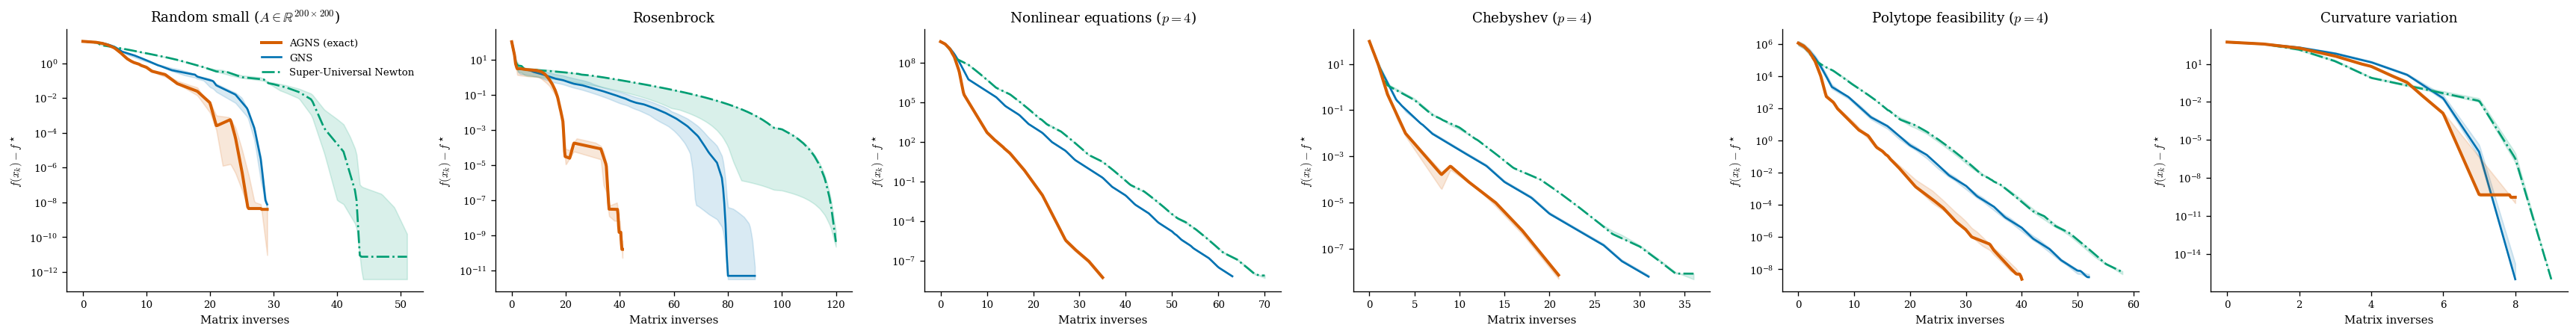

In [3]:
fig = cross_problem_figure(
    specs,
    methods,
    n_iters=n_iters,
    seeds=seeds,
    x_key="matrix_inverses",
    save_as="fig0_sanity.pdf",
)

## Conclusion

The machinery is trustworthy: on a benign instance of every family, AGNS, GNS, and Super-Universal Newton all reach the known optimum, the pure-descent steps are monotone, and AGNS's only non-monotonicity is the occasional single-step overshoot that the adaptive restart exists to control. With the validity gate green we can proceed to the research questions — RQ1 (does explicit momentum accelerate GNS, and through what mechanism?), RQ2 (how much does the restart matter?), RQ3 (explicit versus implicit acceleration), and RQ4 (does it survive an approximate Hessian?).